In [13]:
import ctypes as ct
import MDAnalysis as mda
import MDA_unwrap_PBC as pbc
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import mda_3d_2pt as vd

In [ ]:
TOPOL = "mda_3d_2pt/data/run-NVE.tpr"
TRAJ = "mda_3d_2pt/data/run-NVE_test.trr"
u = mda.Universe(TOPOL,TRAJ)
unwrap = pbc.unwrap(u)
sel = u.select_atoms("resname POPC")
vdos = vd.vdos(sel,200)

building intra-molecular bond trees ...
unwrap -> detected 8016 molecules
unwrap -> tree building time: 0.79s
unwrap -> ready to unwrap


In [15]:
vd.vdosLib.omp_set_num_threads(4)
tStep = 0
for ts in tqdm(u.trajectory):
    unwrap.single_frame()
    vdos.single_frame(tStep,ts.time)
    tStep += 1

100%|██████████| 262/262 [00:03<00:00, 78.53it/s] 


In [16]:
# we post-process a copy of our data allowing us to keep accumulating data
vdos.copyResidueList()
vdos.postProcess(vdos.residueListCopy, mode = "all")
vdos.outputGeometry("residueProperties.dat",vdos.residueListCopy)
vdos.outputVACF("VACF.dat")
vdos.outputVDoS("VDoS.dat")

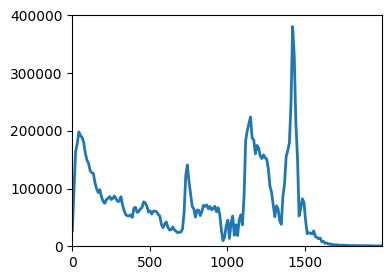

In [17]:
# plot
data=np.array(vdos.totVDoS[0])
fig, ax = plt.subplots()
ax.plot(vdos.wavenumber, data, linewidth = 2.0)
ax.set(xlim=(0, 2000), xticks=np.arange(0,2000,500),
       ylim=(0, 400000.0), yticks=np.arange(0,400001,100000))
plt.show()